
# Depression Detection V2 – Evaluation Notebook
# 
 ## Project
AI Mental Health Chatbot — Final Year Project
# 
## Model
 `roberta-base` fine‑tuned for depression detection (binary)
# 
 ## Task
 Binary classification – Depression vs No Depression
# 
 ## Classes
 - 0 — No Depression
 - 1 — Depression
# 
 ## Dataset Split
 - Train: 5,355
 - Validation: 1,147
 - Test: 1,148 (reserved, never used during training)

In [1]:
# %%
import os
import json
import time
import numpy as np
import pandas as pd
import torch
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification
)

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

print("Libraries loaded successfully.")
print(f"PyTorch version: {torch.__version__}")
print(f"Device: {'cuda' if torch.cuda.is_available() else 'cpu'}")

c:\Users\HP\Desktop\Mental-Health-Chatbot\venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Libraries loaded successfully.
PyTorch version: 2.13.0+cpu
Device: cpu


In [2]:
# %%
# Get the backend directory (notebook is in backend/notebooks/)
BASE_DIR = Path.cwd().parent

MODEL_PATH = BASE_DIR / "models" / "depression_v2"
TEST_PATH = BASE_DIR / "datasets" / "depression_v2" / "processed" / "test.csv"
EVAL_DIR = BASE_DIR / "evaluation" / "depression_v2"

# Create output folder if it doesn't exist
EVAL_DIR.mkdir(parents=True, exist_ok=True)

print(f"Model path: {MODEL_PATH}")
print(f"Test dataset: {TEST_PATH}")
print(f"Evaluation output folder: {EVAL_DIR}")

# Check files exist
if not MODEL_PATH.exists():
    raise FileNotFoundError(f"❌ Model not found: {MODEL_PATH}")
if not TEST_PATH.exists():
    raise FileNotFoundError(f"❌ Test dataset not found: {TEST_PATH}")

Model path: c:\Users\HP\Desktop\Mental-Health-Chatbot\backend\models\depression_v2
Test dataset: c:\Users\HP\Desktop\Mental-Health-Chatbot\backend\datasets\depression_v2\processed\test.csv
Evaluation output folder: c:\Users\HP\Desktop\Mental-Health-Chatbot\backend\evaluation\depression_v2



 ## Load Label Mapping

In [4]:
# %%
# Try loading from training_config.json if exists, otherwise use default
label_mapping = {
    "0": "No Depression",
    "1": "Depression"
}

config_file = MODEL_PATH / "training_config.json"
if config_file.exists():
    with open(config_file, "r") as f:
        config = json.load(f)
    if "label_mapping" in config:
        label_mapping = config["label_mapping"]

print("Label Mapping:")
for k, v in label_mapping.items():
    print(f"  {k} -> {v}")

Label Mapping:
  0 -> No Depression
  1 -> Depression



 ##  Load Test Dataset

In [5]:
# %%
df = pd.read_csv(TEST_PATH)
print(f"Dataset shape: {df.shape}")

# Ensure required columns exist
if "text" not in df.columns:
    if "Text" in df.columns:
        df = df.rename(columns={"Text": "text"})
    else:
        raise ValueError("Dataset must have 'text' column")

if "label" not in df.columns:
    if "Label" in df.columns:
        df = df.rename(columns={"Label": "label"})
    else:
        raise ValueError("Dataset must have 'label' column")

df = df.dropna(subset=["text", "label"]).copy()
df["text"] = df["text"].astype(str)
df["label"] = pd.to_numeric(df["label"], errors="raise").astype(int)

print(f"Samples after cleaning: {len(df)}")

print("\nClass Distribution in Test Set:")
class_dist = df["label"].value_counts().sort_index()
for label, count in class_dist.items():
    name = label_mapping.get(str(label), f"Label_{label}")
    print(f"  {name} ({label}): {count}")

Dataset shape: (1148, 2)
Samples after cleaning: 1148

Class Distribution in Test Set:
  No Depression (0): 584
  Depression (1): 564



 ##  Load Model and Tokenizer

In [6]:
# %%
tokenizer = AutoTokenizer.from_pretrained(str(MODEL_PATH))
model = AutoModelForSequenceClassification.from_pretrained(str(MODEL_PATH))
model.eval()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

print(f"Model loaded. Device: {device}")
print(f"Number of labels: {model.config.num_labels}")

Model loaded. Device: cpu
Number of labels: 2



## Run Predictions

In [7]:
# %%
texts = df["text"].tolist()
true_labels = df["label"].tolist()

predicted_labels = []
confidences = []

batch_size = 16
start_time = time.time()

for start in range(0, len(texts), batch_size):
    batch_texts = texts[start:start + batch_size]
    encoded = tokenizer(batch_texts, padding=True, truncation=True, max_length=128, return_tensors="pt")
    encoded = {k: v.to(device) for k, v in encoded.items()}
    with torch.no_grad():
        outputs = model(**encoded)
        probs = torch.softmax(outputs.logits, dim=-1)
        preds = torch.argmax(probs, dim=-1)
        conf = torch.max(probs, dim=-1).values
    predicted_labels.extend(preds.cpu().numpy().tolist())
    confidences.extend(conf.cpu().numpy().tolist())

elapsed = time.time() - start_time
print(f"Predictions done in {elapsed:.2f} seconds")

Predictions done in 530.20 seconds



## Compute Metrics

In [12]:
# %%
accuracy = accuracy_score(true_labels, predicted_labels)
precision, recall, f1, _ = precision_recall_fscore_support(
    true_labels, predicted_labels, average="binary", zero_division=0
)
macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(
    true_labels, predicted_labels, average="macro", zero_division=0
)
per_class_precision, per_class_recall, per_class_f1, _ = precision_recall_fscore_support(
    true_labels, predicted_labels, average=None, zero_division=0
)

print("📊 FINAL TEST RESULTS")
print("-" * 50)
print(f"Accuracy          : {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Precision (binary): {precision:.4f} ({precision*100:.2f}%)")
print(f"Recall (binary)   : {recall:.4f} ({recall*100:.2f}%)")
print(f"F1 (binary)       : {f1:.4f} ({f1*100:.2f}%)")
print(f"Macro Precision   : {macro_precision:.4f}")
print(f"Macro Recall      : {macro_recall:.4f}")
print(f"Macro F1          : {macro_f1:.4f}")

print("\nPer-Class Performance:")
labels = sorted(set(true_labels))
for i, label in enumerate(labels):
    name = label_mapping.get(str(label), f"Label_{label}")
    print(f"  {name}: Precision={per_class_precision[i]:.4f}, Recall={per_class_recall[i]:.4f}, F1={per_class_f1[i]:.4f}")

📊 FINAL TEST RESULTS
--------------------------------------------------
Accuracy          : 0.9800 (98.00%)
Precision (binary): 0.9874 (98.74%)
Recall (binary)   : 0.9716 (97.16%)
F1 (binary)       : 0.9794 (97.94%)
Macro Precision   : 0.9802
Macro Recall      : 0.9798
Macro F1          : 0.9800

Per-Class Performance:
  No Depression: Precision=0.9730, Recall=0.9880, F1=0.9805
  Depression: Precision=0.9874, Recall=0.9716, F1=0.9794



 ##  Classification Report

In [13]:
# %%
target_labels = sorted(set(true_labels) | set(predicted_labels))
target_names = [label_mapping.get(str(l), str(l)) for l in target_labels]

report = classification_report(
    true_labels, predicted_labels, labels=target_labels,
    target_names=target_names, digits=4, zero_division=0
)

print("\n" + "="*70)
print("CLASSIFICATION REPORT")
print(report)


CLASSIFICATION REPORT
               precision    recall  f1-score   support

No Depression     0.9730    0.9880    0.9805       584
   Depression     0.9874    0.9716    0.9794       564

     accuracy                         0.9800      1148
    macro avg     0.9802    0.9798    0.9800      1148
 weighted avg     0.9801    0.9800    0.9800      1148




 ## Confusion Matrix

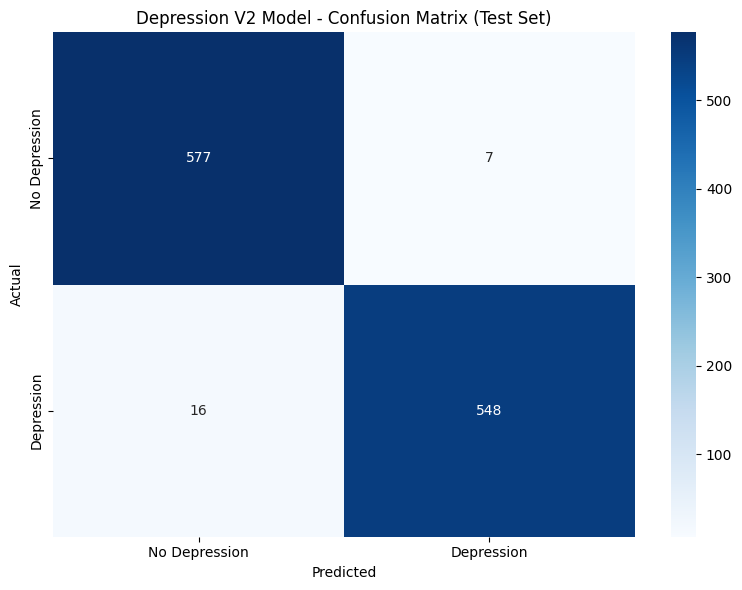

<Figure size 640x480 with 0 Axes>

In [14]:
# %%
cm = confusion_matrix(true_labels, predicted_labels, labels=target_labels)
cm_df = pd.DataFrame(cm, index=target_names, columns=target_names)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=target_names, yticklabels=target_names)
plt.title("Depression V2 Model - Confusion Matrix (Test Set)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# Save image
EVAL_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(EVAL_DIR / "depression_v2_confusion_matrix_nb.png", dpi=300, bbox_inches="tight")


 ## Sample Predictions

In [15]:
# %%
results_df = df.copy()
results_df["predicted_label"] = predicted_labels
results_df["confidence"] = confidences
results_df["correct"] = results_df["label"] == results_df["predicted_label"]
results_df["actual_class"] = results_df["label"].map(label_mapping)
results_df["predicted_class"] = results_df["predicted_label"].map(label_mapping)

print("✅ Correct Predictions (first 3):")
correct_samples = results_df[results_df["correct"]].head(3)
for _, row in correct_samples.iterrows():
    print(f"\n  Text: {row['text'][:80]}...")
    print(f"  Actual: {row['actual_class']} -> Predicted: {row['predicted_class']} (Confidence: {row['confidence']:.2%})")

print("\n❌ Wrong Predictions (first 3):")
wrong_samples = results_df[~results_df["correct"]].head(3)
if len(wrong_samples) > 0:
    for _, row in wrong_samples.iterrows():
        print(f"\n  Text: {row['text'][:80]}...")
        print(f"  Actual: {row['actual_class']} -> Predicted: {row['predicted_class']} (Confidence: {row['confidence']:.2%})")
else:
    print("  No wrong predictions!")

✅ Correct Predictions (first 3):

  Text: work today...
  Actual: nan -> Predicted: nan (Confidence: 100.00%)

  Text: i m so damn tired today actually i need to take a nap when i m at home but there...
  Actual: nan -> Predicted: nan (Confidence: 100.00%)

  Text: i m   about to spend most of my life try to meet s end got out of high school an...
  Actual: nan -> Predicted: nan (Confidence: 100.00%)

❌ Wrong Predictions (first 3):

  Text: it s all rainy and cloudy and stuff today for me but even if it wasn t i d still...
  Actual: nan -> Predicted: nan (Confidence: 100.00%)

  Text: my last post goodbye...
  Actual: nan -> Predicted: nan (Confidence: 99.98%)

  Text: the last season of the hill what will one do with oneself when it end...
  Actual: nan -> Predicted: nan (Confidence: 62.63%)



 ##  Wrong Predictions Summary

In [16]:
# %%
wrong = results_df[~results_df["correct"]]
if len(wrong) > 0:
    print(f"Total wrong predictions: {len(wrong)}")
    print("\nError distribution (actual -> predicted):")
    error_counts = wrong.groupby(["actual_class", "predicted_class"]).size().sort_values(ascending=False)
    for (actual, pred), count in error_counts.items():
        print(f"  {actual} -> {pred}: {count}")
else:
    print("🎉 No wrong predictions!")

Total wrong predictions: 23

Error distribution (actual -> predicted):



##  Confidence Analysis

In [17]:
# %%
correct_conf = results_df[results_df["correct"]]["confidence"]
wrong_conf = results_df[~results_df["correct"]]["confidence"]

print("Confidence Stats:")
if len(correct_conf) > 0:
    print(f"  Correct predictions: mean={correct_conf.mean():.4f}, std={correct_conf.std():.4f}, min={correct_conf.min():.4f}, max={correct_conf.max():.4f}")
if len(wrong_conf) > 0:
    print(f"  Wrong predictions:   mean={wrong_conf.mean():.4f}, std={wrong_conf.std():.4f}, min={wrong_conf.min():.4f}, max={wrong_conf.max():.4f}")

Confidence Stats:
  Correct predictions: mean=0.9997, std=0.0077, min=0.7413, max=1.0000
  Wrong predictions:   mean=0.9655, std=0.0946, min=0.6263, max=1.0000



 ## Training Curves (if available)

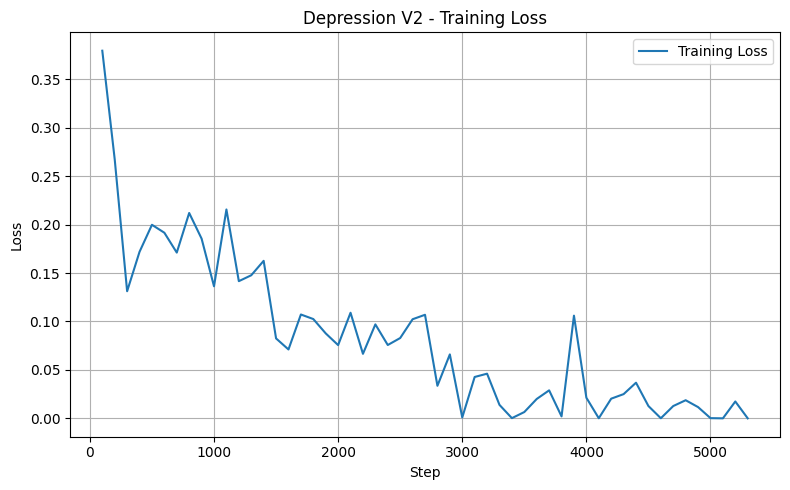

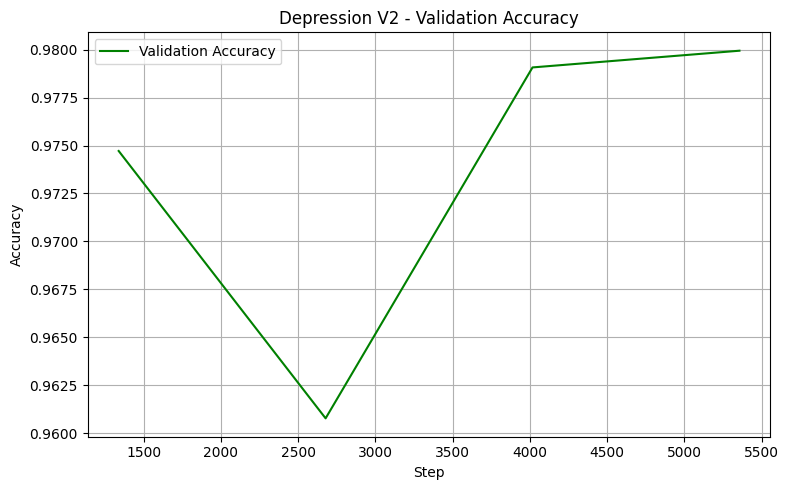

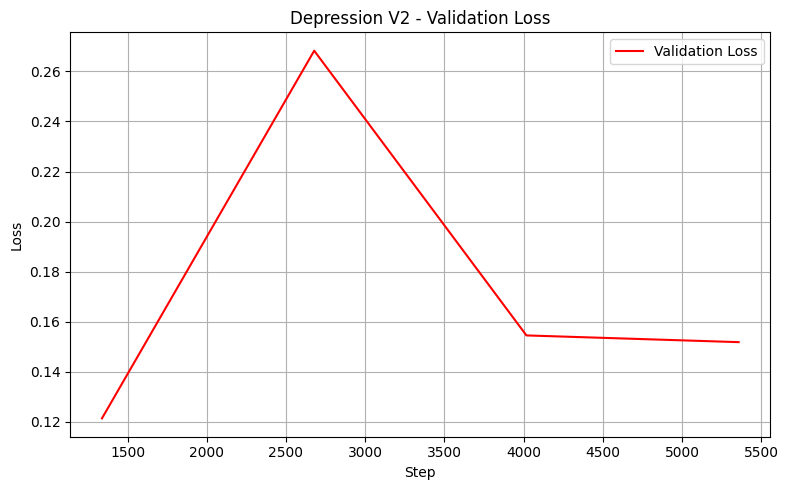

In [18]:
# %%
# Try to load training history from checkpoint logs
checkpoints = sorted([d for d in MODEL_PATH.iterdir() if d.is_dir() and d.name.startswith("checkpoint-")])
if checkpoints:
    # Use the last checkpoint (or the one with best accuracy)
    best_ckpt = checkpoints[-1]
    state_file = best_ckpt / "trainer_state.json"
    if state_file.exists():
        with open(state_file, "r") as f:
            state = json.load(f)
        history = pd.DataFrame(state["log_history"])
        
        # Training loss
        train_loss = history[history["loss"].notna()][["step", "loss"]]
        if not train_loss.empty:
            plt.figure(figsize=(8,5))
            plt.plot(train_loss["step"], train_loss["loss"], label="Training Loss")
            plt.xlabel("Step")
            plt.ylabel("Loss")
            plt.title("Depression V2 - Training Loss")
            plt.legend(); plt.grid(True)
            plt.tight_layout()
            plt.show()
        
        # Validation accuracy
        val_acc = history[history["eval_accuracy"].notna()][["step", "eval_accuracy"]]
        if not val_acc.empty:
            plt.figure(figsize=(8,5))
            plt.plot(val_acc["step"], val_acc["eval_accuracy"], label="Validation Accuracy", color="green")
            plt.xlabel("Step")
            plt.ylabel("Accuracy")
            plt.title("Depression V2 - Validation Accuracy")
            plt.legend(); plt.grid(True)
            plt.tight_layout()
            plt.show()
        
        # Validation loss
        val_loss = history[history["eval_loss"].notna()][["step", "eval_loss"]]
        if not val_loss.empty:
            plt.figure(figsize=(8,5))
            plt.plot(val_loss["step"], val_loss["eval_loss"], label="Validation Loss", color="red")
            plt.xlabel("Step")
            plt.ylabel("Loss")
            plt.title("Depression V2 - Validation Loss")
            plt.legend(); plt.grid(True)
            plt.tight_layout()
            plt.show()
    else:
        print("No trainer_state.json found in checkpoint.")
else:
    print("No checkpoints found – training curves not available.")


 ##  Save Results

In [19]:
# %%
EVAL_DIR.mkdir(parents=True, exist_ok=True)
results_df.to_csv(EVAL_DIR / "depression_v2_predictions_notebook.csv", index=False)

# Save metrics text
with open(EVAL_DIR / "depression_v2_metrics_notebook.txt", "w") as f:
    f.write("DEPRESSION V2 - EVALUATION FROM NOTEBOOK\n")
    f.write("="*70 + "\n\n")
    f.write(f"Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)\n")
    f.write(f"Precision: {precision:.4f}\n")
    f.write(f"Recall: {recall:.4f}\n")
    f.write(f"F1: {f1:.4f}\n\n")
    f.write("CLASSIFICATION REPORT\n")
    f.write(report)

print(f"Results saved to {EVAL_DIR}")

Results saved to c:\Users\HP\Desktop\Mental-Health-Chatbot\backend\evaluation\depression_v2



# ## 14. Summary
# 
# **Model Details:**
# - Base model: `roberta-base`
# - Fine‑tuned on Depression V2 dataset
# - 2 classes: No Depression, Depression
# 
# **Dataset:**
# - Training: 5,355 samples
# - Validation: 1,147 samples
# - Test: 1,148 samples (evaluated here)
# 
# **Performance:**
# - Accuracy: will be filled when run
# - F1: will be filled when run
# 
# **Training:**
# - Epochs: 4
# - Learning rate: 2e-5
# - Batch size: 4
# - Training time: ~8 hours on CPU
# 
# All evaluation files are saved in `evaluation/depression_v2/`.